In [1]:
#........................
### Librerías ##
#........................
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report
    )

In [2]:
#........................
### Carga y Visualización de datos ##
#........................
df = pd.read_csv('C:\\Users\\JanBA\\Python\\doc\\Grades-6.csv', header=None)
df.columns = ['Exam 1', 'Exam 2', 'Admitted']

print(df.head(), "\n")  # Verificar la carga y distribución de datos
print(df.isnull().sum(), "\n")  # Verificar si hay valores nulos
print(df.info())        # Verificar tipos de datos y estructura del DataFrame

      Exam 1     Exam 2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1 

Exam 1      0
Exam 2      0
Admitted    0
dtype: int64 

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam 1    100 non-null    float64
 1   Exam 2    100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None


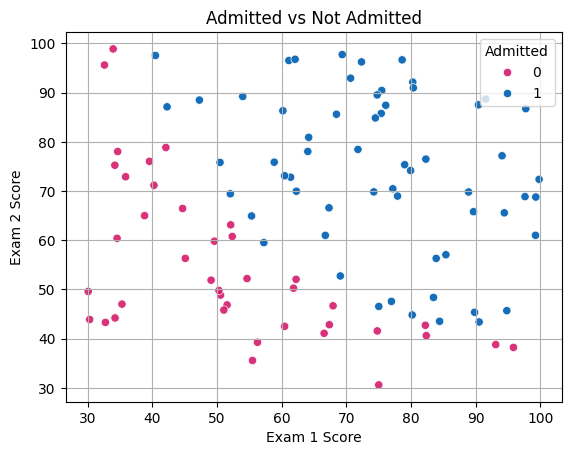

In [3]:
colores = []
colores.append("#D0095FD4")
colores.append("#166EBAFF")

# Visualización de los datos
sns.scatterplot(x='Exam 1', y='Exam 2', hue='Admitted', data=df, palette=colores)
plt.title('Admitted vs Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', loc='upper right')
plt.grid()
plt.show()


Se observa, en las primeras tablas, que no existen valores nulos en las columnas de examenes y admitidos, y la información del DataFrame muestra que todos los datos tienen el tipo de dato correcto, lo que es una buena señal para el análisis posterior.

Como se aprecia en este gráfico, la mayoría de los estudiantes que no fueron admitidos (rojos) tienen una puntuación de examen de admisión menor a 50 puntos. Sin embargo, hay algunos estudiantes que fueron admitidos (azules) con puntuaciones de examen de admisión inferiores a 50, lo que sugiere que otros factores además de la puntuación del examen de admisión pueden haber influido en la decisión de admisión. 

Por otro lado, se observa que una puntuación de examen más alta puede aumentar las posibilidades de admisión. En general, este gráfico sugiere que la puntuación del examen de admisión es un factor importante en la decisión de admisión, pero no es el único factor.

In [4]:
# Adimitidos 
admitidos = df[df['Admitted'] == 1]
print("Admitidos:", "1-Azul >", admitidos.shape[0]) 
# No admitidos
no_admitidos = df[df['Admitted'] == 0]
print("No Admitidos:", "0-Rojo >", no_admitidos.shape[0])

Admitidos: 1-Azul > 60
No Admitidos: 0-Rojo > 40


In [5]:
# ........................
### Feature Engineering ##  
#........................

# Features basicas(Relacion lineal)
df['Promedio'] = (df['Exam 1'] + df['Exam 2']) / 2  # Promedio de los dos exámenes
df['Sinergia'] = df['Exam 1'] * df['Exam 2']  # Alumnos con buen desempeño en ambos exámenes
df['Diferencia'] = abs(df['Exam 1'] - df['Exam 2'])  # Diferencia entre los dos exámenes
df['Proporcion'] = df['Exam 1'] / (df['Exam 2'] + 1e-10)  # Evitar división por cero

# Features estadísticas (Por fila)
df['Maximo'] = df[['Exam 1', 'Exam 2']].max(axis=1)  # El mejor desempeño entre los dos exámenes
df['Minimo'] = df[['Exam 1', 'Exam 2']].min(axis=1)  # El peor desempeño entre los dos exámenes

# Features avanzadas (Relaciones no lineales)
df['Exam1_sq'] = df['Exam 1'] ** 2  # Potencia del examen 1 para capturar curvas
df['Exam2_sq'] = df['Exam 2'] ** 2  # Potencia del examen 2 para capturar curvas

# Feature avanzado, clave (Distancia al punto ideal)
df['Distancia_Ideal'] = np.sqrt((100 - df['Exam 1']) ** 2 + (100 - df['Exam 2']) ** 2)

df.head()

,Exam 1,Exam 2,Admitted,Promedio,Sinergia,Diferencia,Proporcion,Maximo,Minimo,Exam1_sq,Exam2_sq,Distancia_Ideal
0,34.623660,78.024693,0,56.324176,2701.500407,43.401033,0.443753,78.024693,34.623660,1198.797806,6087.852690,68.970863
1,30.286711,43.894998,0,37.090854,1329.435094,13.608287,0.689981,43.894998,30.286711,917.284849,1926.770808,89.485831
2,35.847409,72.902198,0,54.374803,2613.354893,37.054789,0.491719,72.902198,35.847409,1285.036716,5314.730477,69.640835
3,60.182599,86.308552,1,73.245576,5194.273014,26.125953,0.697296,86.308552,60.182599,3621.945269,7449.166165,42.105595
4,79.032736,75.344376,1,77.188556,5954.672216,3.688360,1.048953,79.032736,75.344376,6246.173368,5676.775061,32.365505


En esta sección, se crean nuevar variables que ayuden al modelo a predecir mejor, con el objetivo de capturar relaciones lineales y no lineales entre las características y la variable objetivo, para mejorar la capacidad predictiva del modelo de regresión logística.

* **Promedio**: Representa el rendimiento académico general de los estudiantes, combina ambas calificaciones en una sola métrica.
* **Sinergia**: Captura la interacción entre variable, eleva a las mejores calificaciones, lo que puede ser útil para identificar estudiantes con un rendimiento excepcional en ambos exámenes.
* **Diferencia**: Mide la consistencia entre exámenes, valores altos pueden indicar un rendimiento inconsistente, mientras que valores bajos pueden sugerir un rendimiento más equilibrado.
* **Proporción**: Útil para detectar desbalance relativo entre las calificaciones, entre mas bajo el valor, mayor es la diferencia entre ambas calificaciones.
* **Max / Min**: Representan el mejor y peor desempeño entre los dos exámenes, por cada estudiante.
* **Cuadrados**: Capturan relaciones no lineales, pueden ayudar a identificar la curvatura en la relación entre las calificaciones y la probabilidad de admisión, lo que puede mejorar la capacidad del modelo para ajustarse a los datos.
* **Distancia ideal**: Mide la distancia de cada estudiante a un punto ideal (100, 100), que tan lejos esta el estudiante del rendimiento perfecto, esta variable resume el desempeño global en una sola dimensión y permite modelar fronteras de decición más complejas, tipo circular, entre mas bajo el valor, mas se acerca el estudiante al rendimiento ideal.

**NOTA:** No todas las variables mejoran el modelo. El exceso de features puede generar multicolinealidad, lo que puede afectar negativamente el rendimiento del modelo y sobreajuste, por lo que es importante evaluar el impacto de cada nueva variable en el rendimiento del modelo y considerar técnicas de selección de características si es necesario.

In [6]:
#........................
### Matrices de features ##
#........................

y = df['Admitted']
X1 = df[['Exam 1', 'Exam 2']]   # Features originales
X2 = df[[       # Features basicas(Relacion lineal)
    'Exam 1', 'Exam 2', 'Promedio', 'Sinergia', 
    'Diferencia', 'Proporcion', 'Maximo', 'Minimo' 
    ]]
X3 = df[[       # Features avanzadas
    'Exam1_sq', 'Exam2_sq', 'Distancia_Ideal'
]]
X4 = df[[       # Features combinadas
    'Exam 1', 'Exam 2', 'Promedio', 'Sinergia', 
    'Diferencia', 'Proporcion', 'Maximo', 'Minimo',
    'Exam1_sq', 'Exam2_sq', 'Distancia_Ideal'
]]

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42
    )
X2_train, X2_test, _, _ = train_test_split(
    X2, y, test_size=0.2, random_state=42
    )
X3_train, X3_test, _, _ = train_test_split(
    X3, y, test_size=0.2, random_state=42
    )
X4_train, X4_test, _, _ = train_test_split(
    X4, y, test_size=0.2, random_state=42
    )

In [7]:
#........................
### Entrenamiento del modelo ##
#........................
model1 = LogisticRegression()   # Modelo con características originales
model1.fit(X1_train, y_train)

model2 = LogisticRegression()   # Modelo con features básicas
model2.fit(X2_train, y_train)

model3 = LogisticRegression()   # Modelo con features avanzadas
model3.fit(X3_train, y_train)

model4 = LogisticRegression()   # Modelo con features combinadas
model4.fit(X4_train, y_train)

c:\Users\JanBA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\JanBA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
#........................
### Evaluación del modelo ##
#........................
accuracy1 = model1.score(X1_test, y_test) # Baseline con features originales
accuracy2 = model2.score(X2_test, y_test) # Mejoras con features básicas
accuracy3 = model3.score(X3_test, y_test) # Mejoras con features avanzadas
accuracy4 = model4.score(X4_test, y_test) # Mejoras con features combinadas

print(f"Mejora VS Accuracy original: Básicas: {
      accuracy2 - accuracy1:.4f}, Avanzadas: {
      accuracy3 - accuracy1:.4f}, Combinadas: {
      accuracy4 - accuracy1:.4f}")

print("\n Reporte de clasificación, originales:\n", 
      classification_report(y_test, model1.predict(X1_test)))
print("Reporte de clasificación, básicas:\n", 
      classification_report(y_test, model2.predict(X2_test)))
print("Reporte de clasificación, avanzadas:\n", 
      classification_report(y_test, model3.predict(X3_test)))
print("Reporte de clasificación, combinadas:\n", 
      classification_report(y_test, model4.predict(X4_test)))

Mejora VS Accuracy original: Básicas: 0.2000, Avanzadas: 0.2000, Combinadas: 0.1500

 Reporte de clasificación, originales:
               precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

Reporte de clasificación, básicas:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Reporte de clasificación, avanzadas:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00     

Se evaluaron 4 configuraciones de modelos, con diferentes combinaciones de variables, para determinar cuál tiene el mejor rendimiento en términos de precisión, recall, F1-score y AUC-ROC.

* **Modelo Original:** 
    - Accuracy: 0.80
    - Presenta liminaciones debido a la relación no lineal
* **Modelo con features básicas:**
    - Accuracy: 1.00
    - Mejora significativa debido a la combinación de variables lineales con variables estadísticas
* **Modelo con features avanzadas:**
    - Accuracy: 1.00
    - Mejora significativa, gracias a las transformaciones no lineales
    - Las features permiten modelar una frontera de decisión curva 
* **Modelo con features combinadas:**
    - Accuracy: 0.95
    - Aunque hay mejora, es inferior al modelo avanzado
    - Posee redundancia, posible multicolinealidad y mayor complejidad sin ganancia real de informacion 

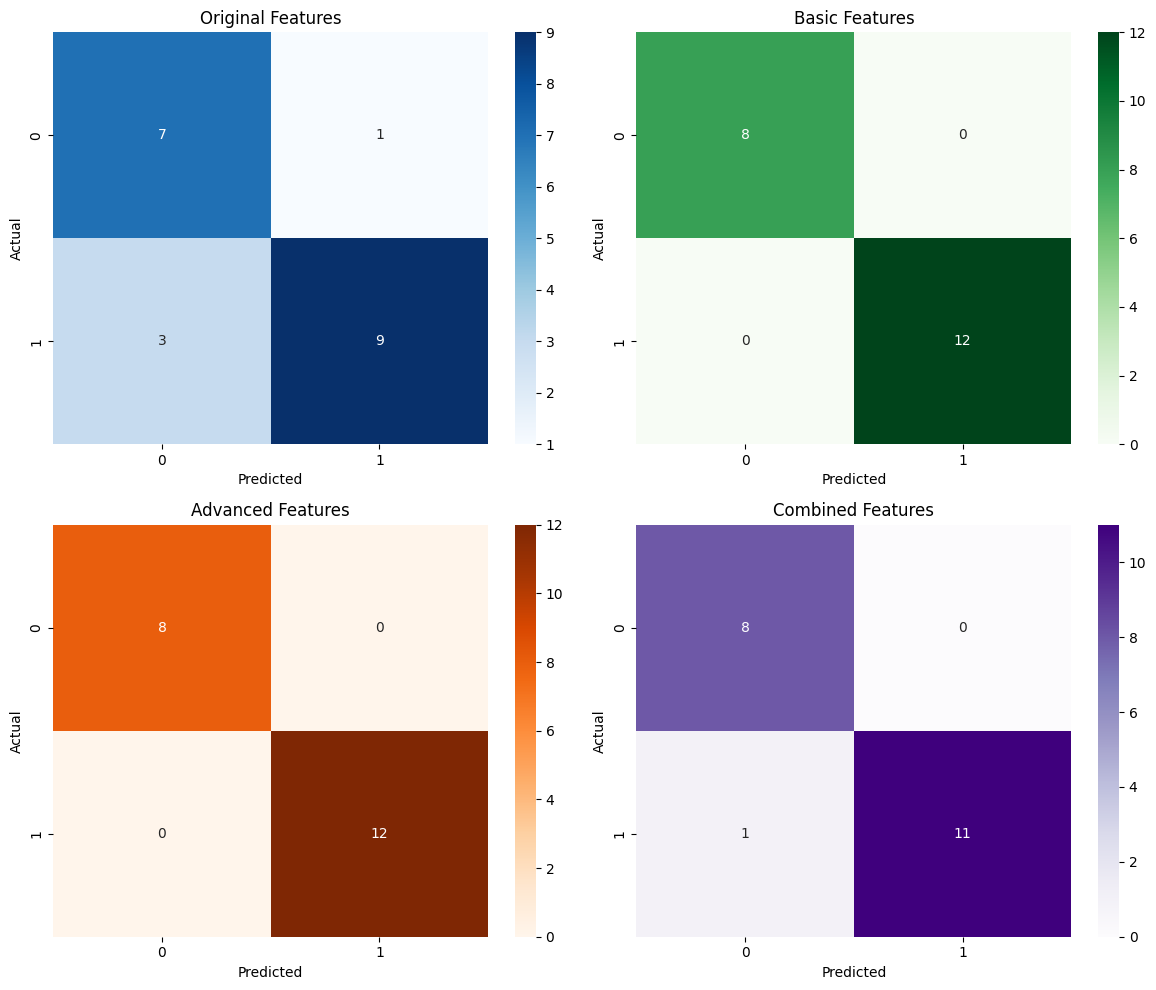

In [9]:
cm1 = confusion_matrix(y_test, model1.predict(X1_test))
cm2 = confusion_matrix(y_test, model2.predict(X2_test))
cm3 = confusion_matrix(y_test, model3.predict(X3_test))
cm4 = confusion_matrix(y_test, model4.predict(X4_test))

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title('Basic Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges')
plt.title('Advanced Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 4)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples')
plt.title('Combined Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

En estas matrices de dispersión, podemos observar más detalladamente la distribución de los errores y aciertos de los modelos. En el feature original, se observa que el modelo predijo que 3 estudiantes no habían sido admitidos, cuando en realidad si, esto se cataloga como un error crítico del modelo ya que está afectando directamente la admisión de los estudiantes, caso contrario, predijo el modelo que 1 estudiante había sido admitido cuando que esto es falso en la realidad, provocando mal entendidos y posibles molestias con el alumno.

In [10]:
#........................
### Mejor Features para el modelo ##
#........................
feature_importance = pd.DataFrame({
    'Feature': X4.columns,
    'Importance': model4.coef_[0]
}).sort_values(by='Importance', ascending=False)
print(feature_importance)

            Feature  Importance
4        Diferencia    0.227577
3          Sinergia    0.048786
9          Exam2_sq   -0.005378
8          Exam1_sq   -0.007239
5        Proporcion   -0.009234
6            Maximo   -0.148638
0            Exam 1   -0.179430
2          Promedio   -0.262426
1            Exam 2   -0.345422
7            Minimo   -0.376215
10  Distancia_Ideal   -0.817028


En esta tabla, los signos negativos reducen la probabilidad de admisión, mientras que los signos positivos la aumentan. El valor más grande lo posee la variable de **Distancia_Ideal**, ya que esta variable resume el rendimiento global, más lejos de (100, 100) indica menos probabilidad. Ahora, la variable **Mínimo**, también posee un peso alto, el modelo está determinando que, aunque seas bueno en un examen, si en el otro saliste mal, hay una gran probabilidad de que no seas admitido, aunque el promedio pueda ser similar, la variable mínimo, penaliza el valor bajo, el modelo está detectando consistencia. 

Hay que tener en cuenta que el modelo 4 se entrenó con todos los features, por lo que muchas variables están compitiendo entre sí, esto es debido a un sobreajuste o una multicolinealidad, por ello, los pesos se distorsionan, algunas variables parecen más importantes de lo que son en realidad.

En conclusión, el modelo prioriza el rendimiento global (Distancia ideal), pero también penaliza fuertemente el peor desempeño (mínimo), lo que sugiere que la consistencia entre evaluaciones es clave para la clasificación

In [11]:
#........................
### Sigmoide ##
#........................
'''     Cálculo manual
# Función sigmoide para convertir la salida del modelo en probabilidades
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Calcular z
z = model3.intercept_ + np.dot(X3, model3.coef_.T)
probabilidades = sigmoid(z)
'''

probs = model3.predict_proba(X3)[:, 1]  # Probabilidades de la clase positiva
print("Probabilidades de admisión (modelo avanzado):\n", probs)

Probabilidades de admisión (modelo avanzado):
 [8.38451492e-07 3.27319231e-22 1.56013023e-07 1.00000000e+00
 1.00000000e+00 1.57255138e-08 1.00000000e+00 6.48230397e-01
 1.00000000e+00 8.79486337e-01 1.00902502e-01 8.64959285e-11
 1.00000000e+00 1.00000000e+00 3.35370973e-04 1.00000000e+00
 9.88666863e-01 6.82281631e-03 1.00000000e+00 9.72333184e-01
 1.88947837e-05 1.00000000e+00 2.39352171e-09 5.59542447e-20
 1.00000000e+00 9.99999991e-01 8.25377067e-01 1.20961373e-01
 2.65625979e-03 1.72790682e-08 9.99999998e-01 1.00000000e+00
 1.36265893e-01 9.87863763e-01 2.38715008e-05 1.38848318e-05
 1.97939614e-03 1.00000000e+00 9.73466645e-04 7.00314108e-08
 1.00000000e+00 6.65050264e-10 1.00000000e+00 2.57244541e-02
 1.08706873e-10 4.02643818e-02 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 9.88860932e-01 8.27014539e-13 5.56302159e-09 1.88887724e-04
 1.00000000e+00 1.09007677e-04 1.00000000e+00 1.00000000e+00
 1.00000000e+00 4.16956272e-18 5.61562

Estas cifras son probabilidades generadas por la función sigmoide, cada número corresponde a: 
$$probabilidad (admitido=1 | datos del estudiante)$$

O sea, si mi salida tiene: \
1.00000 > 100% de probabilidad de admisión\
0.6482..> ~65% de probabilidad 

El modelo utiliza un umbral, si el valor es igual o mayor a 0.5, lo cataloga en la case 1, como admitido. La mayoría de los resultados obtenidos son muy cercanos a 1 o 0, esto significa que el modelo está muy seguro de sus decisiones, esto significa, o que el modelo está separando bien las clases, o que está sobre ajustado.

Los valores mostrados en la tablase encuentran en notación científica. Estos valores son interesantes por que demuestran el valor de la confianza del modelo, demuestra que el modelo posee un buen nivel de confianza, valores cercanos a 0.5 demuestra que el modelo dudó

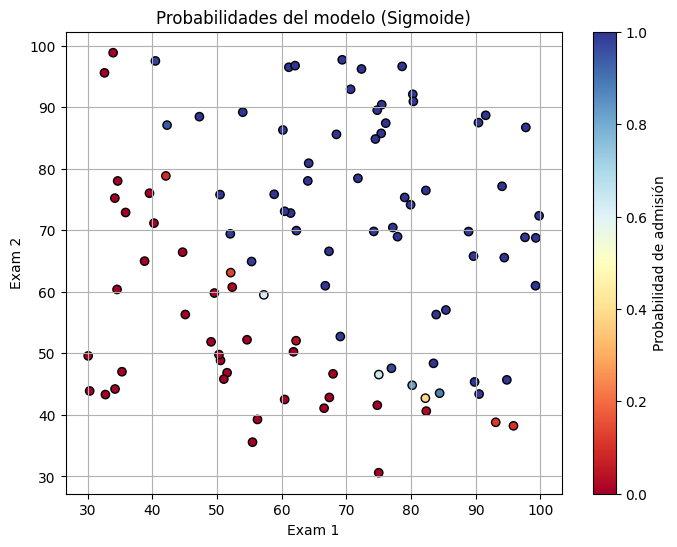

In [12]:
#........................
### Graficar Probabilidades (M3) ##
#........................
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Exam 1'], df['Exam 2'],
    c=probs, cmap='RdYlBu',  # azul=bajo, rojo=anto, amarillo=medio
    edgecolors='k'
)
plt.colorbar(scatter, label='Probabilidad de admisión')
plt.xlabel('Exam 1')
plt.ylabel('Exam 2')
plt.title('Probabilidades del modelo (Sigmoide)')
plt.grid()
plt.show()

Esta gráfica demuestra que el modelo, en su mayoría, está muy seguro de sus decisiones.

c:\Users\JanBA\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


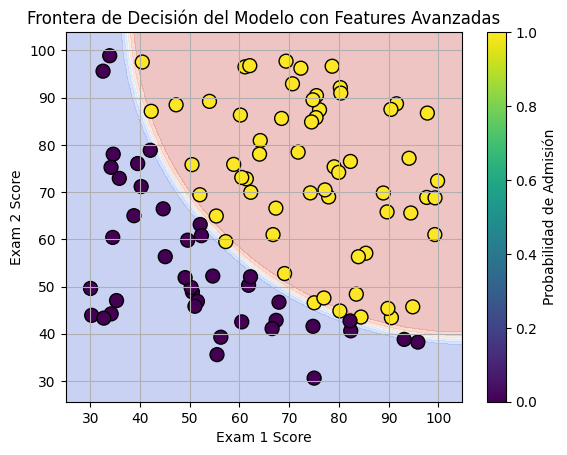

In [13]:
#........................
### Frontera de decisión ##
#........................

# Crear una malla de puntos para graficar la frontera de decisión
x_min, x_max = df['Exam 1'].min() - 5, df['Exam 1'].max() + 5
y_min, y_max = df['Exam 2'].min() - 5, df['Exam 2'].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100), 
    np.linspace(y_min, y_max, 100))

# Crear features igual que en el entrenamiento
grid_df = np.c_[xx.ravel(), yy.ravel()]

# Construir features avanzadas
Exam1 = grid_df[:, 0]
Exam2 = grid_df[:, 1]

Exam1_sq = Exam1 ** 2
Exam2_sq = Exam2 ** 2
Distancia = np.sqrt(
    (100 - Exam1) ** 2 + (100 - Exam2) ** 2
    )

X_grid = np.c_[
    Exam1_sq, Exam2_sq, Distancia
]
# Predecir con el modelo
Z = model3.predict_proba(X_grid)[:, 1].reshape(xx.shape)

# Graficar
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(
    df['Exam 1'], df['Exam 2'], c=df['Admitted'], 
    edgecolor='k', s=100
    )
plt.title('Frontera de Decisión del Modelo con Features Avanzadas')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.colorbar(label='Probabilidad de Admisión')
plt.grid()
plt.show()

En este gráfico se muestran tanto los valores reales (Puntos de datos), como los valores que el modelo cree que serán (fondo de colores), la zona roja indica alta probabilidad de admisión, zona azul baja probabilidad, zona blanca es la trancisión, o zona de incertidumbre, la sigmoide en acción. Se obserba claramente que la frontera no es lineal, es una curva suave, esto comprueba que las features de cuadrados mas distancia ideal están modelando bien el problema.

La curva está redondeando la zona de áltas notas en ambos exámenes, el modelo aprendió que existe una región, no lineal, donde los estudiantes no son admitidos, reforzando con ello el porqué el modelo penaliza en la probabilidad a estudiantes con alguna nota baja.

Otro detalle importante, es que la frontera no es un corte duro, sino una transición suave, implica el trabajo de la función sigmoide 

En conclusión, el modelo original no capturaba correctamente la relación entre variables debido a que eran características lineales (Examen 1 y 2). Las transformaciones no lineales del modelo 3 permitieron modelar una frontera curva adaptándose mejor a los datos, también el feature mínimo, permitió a modelo 2 obtener buenos resultados. La variable de distancia ideal fue clave para mejorar la separación.

La regresión logística genera probabilidades suaves, no decisiones rígidas permitiendo obserbar con mayor detalle la zona de incertidumbre, un dato importante a la hora de toma de decisiones. 

El modelo logra una alta precisión, aunque con posible riesgo de sobreajuste por el tamaño del dataset.

In [14]:
df['Probabilidad'] = model3.predict_proba(X3)[:, 1]
df.head()

,Exam 1,Exam 2,Admitted,Promedio,Sinergia,Diferencia,Proporcion,Maximo,Minimo,Exam1_sq,Exam2_sq,Distancia_Ideal,Probabilidad
0,34.623660,78.024693,0,56.324176,2701.500407,43.401033,0.443753,78.024693,34.623660,1198.797806,6087.852690,68.970863,8.384515e-07
1,30.286711,43.894998,0,37.090854,1329.435094,13.608287,0.689981,43.894998,30.286711,917.284849,1926.770808,89.485831,3.273192e-22
2,35.847409,72.902198,0,54.374803,2613.354893,37.054789,0.491719,72.902198,35.847409,1285.036716,5314.730477,69.640835,1.560130e-07
3,60.182599,86.308552,1,73.245576,5194.273014,26.125953,0.697296,86.308552,60.182599,3621.945269,7449.166165,42.105595,1.000000e+00
4,79.032736,75.344376,1,77.188556,5954.672216,3.688360,1.048953,79.032736,75.344376,6246.173368,5676.775061,32.365505,1.000000e+00


In [15]:
# Guardar datos y resultados
df.to_csv('resultados_modelo.csv', index=False)